In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
train_data = fetch_20newsgroups (
    subset = "train",
    remove = ("headers", "footers", "quotes")
)

In [4]:
test_data = fetch_20newsgroups (
    subset = "test",
    remove = ("headers", "footers", "quotes")
)

In [5]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [6]:
print("Training Documents: ", len(X_train_text))
print("Testing Documents: ", len(X_test_text))
print("Number of Classes: ", len(class_names))

Training Documents:  11314
Testing Documents:  7532
Number of Classes:  20


In [11]:
vectorizer = CountVectorizer(
    stop_words = "english",
    min_df = 2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [13]:
print("Training feature matrix: ", X_train.shape)
print("Testing feature matrix: ", X_test.shape)

Training feature matrix:  (11314, 39115)
Testing feature matrix:  (7532, 39115)


In [19]:
mnb = MultinomialNB()

mnb.fit(
    X_train,
    y_train
)
y_pred_mnb = mnb.predict(X_test)

In [21]:
binary_vectorizer = CountVectorizer(
    stop_words = "english",
    min_df = 2,
    binary = True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [22]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)

y_pred_bnb = bnb.predict(
    X_test_binary
)

In [25]:
results = pd.DataFrame({
    "Model":[
        "Multinomial NB",
        "Bernoulli NB"
    ],
    "Accuracy":[
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],
    "Precision":[
        precision_score(
            y_test,
            y_pred_mnb,
            average = "macro"
        ),
        precision_score(
            y_test,
            y_pred_bnb,
            average = "macro"
        )
    ],
    "Recall":[
        recall_score(
            y_test,
            y_pred_mnb,
            average = "macro"
        ),
        recall_score(
            y_test,
            y_pred_bnb,
            average = "macro"
        )
    ],
    "F1-Score":[
        f1_score(
            y_test,
            y_pred_mnb,
            average = "macro"
        ),
        f1_score(
            y_test,
            y_pred_bnb,
            average = "macro"
        )
    ]
})

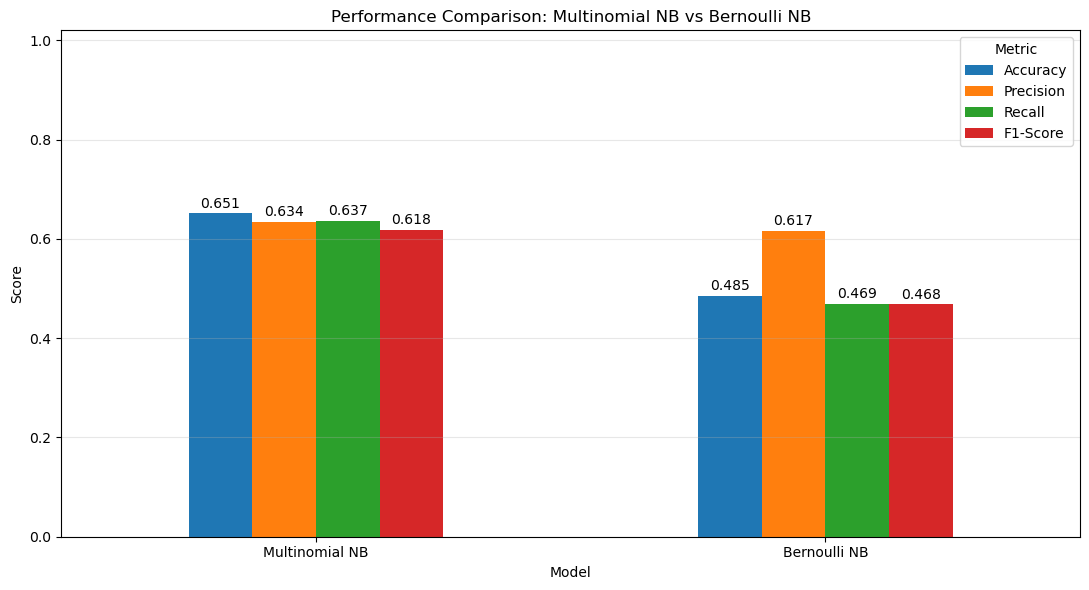

In [27]:
result_metrics = results[
    ["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
]

ax = result_metrics.set_index("Model").plot(
    kind = "bar",
    figsize = (11, 6)
)

plt.title("Performance Comparison: Multinomial NB vs Bernoulli NB")

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.02)

plt.xticks(rotation = 0)
plt.legend(title = "Metric")
plt.grid(
    axis = "y",
    alpha = 0.3
)
#Display values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt = "%.3f",
        padding = 2
    )
plt.tight_layout()
plt.show()